In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
data = load_diabetes()

X = data.data
y = data.target

print("Features:", X.shape)
print("Target:", y.shape)


Features: (442, 10)
Target: (442,)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [4]:
linear = LinearRegression()

linear.fit(X_train, y_train)

prediction = linear.predict(X_test)

In [5]:
mse = mean_squared_error(y_test, prediction)

r2 = r2_score(y_test, prediction)

print("Linear Regression")
print("MSE:", mse)
print("R2 Score:", r2)

Linear Regression
MSE: 2900.193628493482
R2 Score: 0.4526027629719195


In [6]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

ridge_prediction = ridge.predict(X_test)

ridge_mse = mean_squared_error(y_test, ridge_prediction)

ridge_r2 = r2_score(y_test, ridge_prediction)

print("Ridge Regression")
print("MSE:", ridge_mse)
print("R2 Score:", ridge_r2)

Ridge Regression
MSE: 3077.41593882723
R2 Score: 0.41915292635986545


In [7]:
lasso = Lasso(alpha=0.1)

lasso.fit(X_train, y_train)

lasso_prediction = lasso.predict(X_test)

lasso_mse = mean_squared_error(y_test, lasso_prediction)

lasso_r2 = r2_score(y_test, lasso_prediction)

print("Lasso Regression")
print("MSE:", lasso_mse)
print("R2 Score:", lasso_r2)

Lasso Regression
MSE: 2798.193485169719
R2 Score: 0.4718547867276227


In [8]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge", "Lasso"],
    "MSE": [mse, ridge_mse, lasso_mse],
    "R2 Score": [r2, ridge_r2, lasso_r2]
})

comparison

,Model,MSE,R2 Score
0,Linear Regression,2900.193628,0.452603
1,Ridge,3077.415939,0.419153
2,Lasso,2798.193485,0.471855


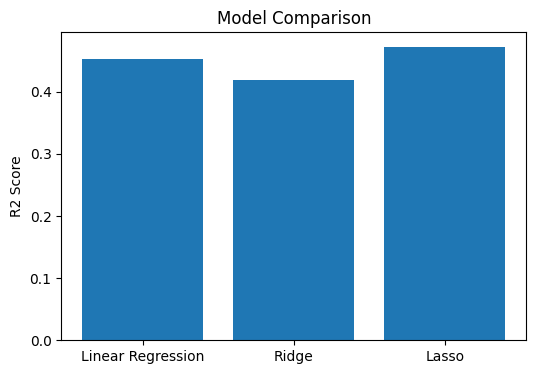

In [9]:
plt.figure(figsize=(6,4))

plt.bar(comparison["Model"], comparison["R2 Score"])

plt.title("Model Comparison")

plt.ylabel("R2 Score")

plt.show()

In [11]:
Conclusion

• Linear Regression is the baseline model.

• Ridge Regression reduces overfitting using L2 regularization.

• Lasso Regression reduces overfitting using L1 regularization and can set some coefficients to zero.

• Regularization helps improve model generalization.